In [1]:
# import libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sn
from scipy.stats import poisson
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# get data

seriea_2425 = pd.read_csv("https://www.football-data.co.uk/mmz4281/2425/I1.csv")
seriea_2425 = seriea_2425[['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG']]
seriea_2425 = seriea_2425.rename(columns={'FTHG': 'HomeGoals', 'FTAG': 'AwayGoals'})
seriea_2425.head()

,HomeTeam,AwayTeam,HomeGoals,AwayGoals
0,Genoa,Inter,2,2
1,Parma,Fiorentina,1,1
2,Empoli,Monza,0,0
3,Milan,Torino,2,2
4,Bologna,Udinese,1,1


In [3]:
print("AVG Home Goals:", seriea_2425['HomeGoals'].mean())
print("AVG Away Goals:", seriea_2425['AwayGoals'].mean())

AVG Home Goals: 1.3394736842105264
AVG Away Goals: 1.2210526315789474


In [4]:
# transform data for modeling

goal_model_data = pd.concat(
    [seriea_2425[['HomeTeam', 'AwayTeam', 'HomeGoals']].assign(home=1).rename(
        columns={'HomeTeam': 'team', 'AwayTeam': 'opponent', 'HomeGoals': 'goals'}),
    seriea_2425[['AwayTeam', 'HomeTeam', 'AwayGoals']].assign(home=0).rename(
        columns={'AwayTeam': 'team', 'HomeTeam': 'opponent', 'AwayGoals': 'goals'})])

goal_model_data.head()

,team,opponent,goals,home
0,Genoa,Inter,2,1
1,Parma,Fiorentina,1,1
2,Empoli,Monza,0,1
3,Milan,Torino,2,1
4,Bologna,Udinese,1,1


In [5]:
goal_model_data.loc[goal_model_data['team'] == 'Milan'].sort_index(ascending=True).head()

,team,opponent,goals,home
3,Milan,Torino,2,1
10,Milan,Parma,1,0
24,Milan,Lazio,2,0
32,Milan,Venezia,4,1
48,Milan,Inter,2,0


In [6]:
goal_model_data.loc[goal_model_data['opponent'] == 'Milan'].sort_index(ascending=True).head()

,team,opponent,goals,home
3,Torino,Milan,2,0
10,Parma,Milan,2,1
24,Lazio,Milan,2,1
32,Venezia,Milan,0,0
48,Inter,Milan,1,1


In [7]:
# run the model

poisson_model = smf.glm(formula="goals ~ home + team + opponent", data=goal_model_data, family=sm.families.Poisson()).fit()

poisson_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  goals   No. Observations:                  760
Model:                            GLM   Df Residuals:                      720
Model Family:                 Poisson   Df Model:                           39
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1031.0
Date:                Thu, 28 Aug 2025   Deviance:                       744.30
Time:                        12:52:38   Pearson chi2:                     638.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1692
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0.4210      0.205      2.051      0.040       0.019       0.823
team[T.Bologna]           -0.3037      0.175     -1.740      0.082      -0.646       0.038
team[T.Cagliari]          -0.6491      0.195     -3.333      0.001      -1.031      -0.267
team[T.Como]              -0.4499      0.183     -2.464      0.014      -0.808      -0.092
team[T.Empoli]            -0.8387      0.208     -4.033      0.000      -1.246      -0.431
team[T.Fiorentina]        -0.2588      0.172     -1.505      0.132      -0.596       0.078
team[T.Genoa]             -0.7348      0.200     -3.676      0.000      -1.127      -0.343
team[T.Inter]              0.0106      0.160      0.066      0.947      -0.303       0.324
team[T.Juventus]          -0.2993      0.174     -1.724      0.085      -0.640       0.041
team[T.Lazio]             -0.2334      0.171     -1.363      0.173      -0.569       0.102
team[T.Lecce]             -1.0408      0.224     -4.656      0.000      -1.479      -0.603
team[T.Milan]             -0.2400      0.171     -1.402      0.161      -0.576       0.096
team[T.Monza]             -0.9925      0.221     -4.499      0.000      -1.425      -0.560
team[T.Napoli]            -0.2908      0.173     -1.683      0.092      -0.629       0.048
team[T.Parma]             -0.5513      0.189     -2.919      0.004      -0.921      -0.181
team[T.Roma]              -0.3345      0.175     -1.907      0.057      -0.678       0.009
team[T.Torino]            -0.6863      0.196     -3.495      0.000      -1.071      -0.301
team[T.Udinese]           -0.6243      0.193     -3.232      0.001      -1.003      -0.246
team[T.Venezia]           -0.8727      0.210     -4.152      0.000      -1.285      -0.461
team[T.Verona]            -0.8011      0.206     -3.893      0.000      -1.205      -0.398
opponent[T.Bologna]        0.2169      0.220      0.985      0.325      -0.215       0.648
opponent[T.Cagliari]       0.3740      0.212      1.763      0.078      -0.042       0.790
opponent[T.Como]           0.3095      0.215      1.437      0.151      -0.113       0.732
opponent[T.Empoli]         0.4188      0.210      1.994      0.046       0.007       0.830
opponent[T.Fiorentina]     0.0832      0.227      0.366      0.714      -0.362       0.528
opponent[T.Genoa]          0.2370      0.218      1.086      0.277      -0.191       0.664
opponent[T.Inter]         -0.0547      0.236     -0.231      0.817      -0.518       0.408
opponent[T.Juventus]      -0.0777      0.236     -0.329      0.742      -0.540       0.385
opponent[T.Lazio]          0.2631      0.218      1.206      0.228      -0.165       0.691
opponent[T.Lecce]          0.3952      0.211      1.876      0.061      -0.018       0.808
opponent[T.Milan]          0.1320      0.225      0.588      0.557      -0.308  

In [8]:
home_team = 'Milan'
away_team = 'Inter'

In [9]:
# find expected mean number of goals for a specific match

home_score_rate = poisson_model.predict(pd.DataFrame(data={'team': home_team, 'opponent': away_team, 'home': 1},index=[1]))
away_score_rate = poisson_model.predict(pd.DataFrame(data={'team': away_team, 'opponent': home_team, 'home': 0},index=[1]))

print(f"Expected number of goals for {home_team} against {away_team}:", str(home_score_rate))
print(f"Expected number of goals for {away_team} against {home_team}:", str(away_score_rate))

Expected number of goals for Milan against Inter: 1    1.24468
dtype: float64
Expected number of goals for Inter against Milan: 1    1.756972
dtype: float64


In [10]:
def simulate_match(foot_model, homeTeam, awayTeam, max_goals=5):
    home_goals_avg = foot_model.predict(pd.DataFrame(data={'team': homeTeam, 'opponent': awayTeam, 'home': 1}, index=[1])).values[0]
    away_goals_avg = foot_model.predict(pd.DataFrame(data={'team': awayTeam, 'opponent': homeTeam, 'home': 0}, index=[1])).values[0]

    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals+1)] for team_avg in [home_goals_avg, away_goals_avg]]
    
    return(np.outer(np.array(team_pred[0]), np.array(team_pred[1])))

In [11]:
score_matrix_acmint = simulate_match(poisson_model, 'Milan', 'Inter')
score_matrix_acmint

array([[0.04970486, 0.08733007, 0.07671826, 0.04493062, 0.01973547,
        0.00693493],
       [0.06186665, 0.108698  , 0.0954897 , 0.05592425, 0.02456434,
        0.00863177],
       [0.0385021 , 0.06764712, 0.05942707, 0.03480391, 0.01528738,
        0.0053719 ],
       [0.01597427, 0.02806634, 0.0246559 , 0.01443991, 0.00634263,
        0.00222877],
       [0.00497071, 0.00873341, 0.00767218, 0.00449327, 0.00197364,
        0.00069353],
       [0.00123739, 0.00217406, 0.00190988, 0.00111854, 0.00049131,
        0.00017264]])

In [12]:
# AC Milan win
ac_milan_win = np.sum(np.tril(score_matrix_acmint, -1))
print("Milan win probability:", ac_milan_win)
print(str(round(ac_milan_win * 100, 2)) + '%')

# draw
draw = np.sum(np.diag(score_matrix_acmint))
print("draw probability:", draw)
print(str(round(draw * 100, 2)) + '%')

# Inter win
inter_win = np.sum(np.triu(score_matrix_acmint, 1))
print("Inter win probability:", inter_win)
print(str(round(inter_win * 100, 2)) + '%')

Milan win probability: 0.26951311611321005
26.95%
draw probability: 0.2344161143340576
23.44%
Inter win probability: 0.4849875137413442
48.5%


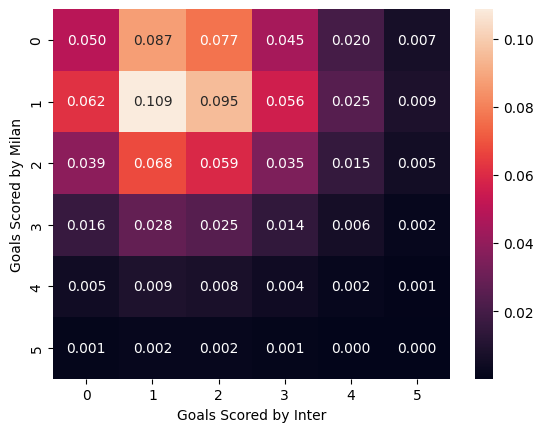

In [13]:
ax = sn.heatmap(score_matrix_acmint, annot=True, fmt=".3f")

ax.set_xlabel(f"Goals Scored by {away_team}")
ax.set_ylabel(f"Goals Scored by {home_team}")

plt.show()